In [1]:
!pip install shap
!pip install osmnx geopy
!pip install xgboost
!pip install catboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
import networkx as nx
import time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
import shap

ox.settings.log_console = False
ox.settings.use_cache = True

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("AmesHousing.csv")

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape

(2930, 82)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [7]:
# Remove identifier columns
df = df.drop(columns=["Order", "PID"], errors="ignore")

In [8]:
# Check missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

In [9]:
missing_values

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

In [10]:
(missing_values / len(df) * 100).sort_values(ascending=True).round(2)

Electrical         0.03
Garage Cars        0.03
BsmtFin SF 1       0.03
Garage Area        0.03
BsmtFin SF 2       0.03
Bsmt Unf SF        0.03
Total Bsmt SF      0.03
Bsmt Half Bath     0.07
Bsmt Full Bath     0.07
Mas Vnr Area       0.78
Bsmt Qual          2.73
Bsmt Cond          2.73
BsmtFin Type 1     2.73
BsmtFin Type 2     2.76
Bsmt Exposure      2.83
Garage Type        5.36
Garage Qual        5.43
Garage Cond        5.43
Garage Yr Blt      5.43
Garage Finish      5.43
Lot Frontage      16.72
Fireplace Qu      48.53
Mas Vnr Type      60.58
Fence             80.48
Alley             93.24
Misc Feature      96.38
Pool QC           99.56
dtype: float64

In [11]:
missing_percent = (missing_values / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

In [12]:
# Separate features and target
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

In [13]:
# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [14]:
# Now missing value check and threshold
missing_summary_train = X_train.isnull().sum() / len(X_train) * 100
columns_to_drop = missing_summary_train[missing_summary_train > 40].index

In [15]:
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

In [16]:
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

In [17]:
for col in numerical_cols:
    if X_train[col].isnull().any():
        median_value = X_train[col].median()      # <- TRAIN parthi j
        X_train[col] = X_train[col].fillna(median_value)
        X_test[col] = X_test[col].fillna(median_value)   # <- SAME value test ma

In [18]:
for col in categorical_cols:
    if X_train[col].isnull().any():
        mode_value = X_train[col].mode()
        if not mode_value.empty:
            fill_value = mode_value.iloc[0]
            X_train[col] = X_train[col].fillna(fill_value)
            X_test[col] = X_test[col].fillna(fill_value)

In [19]:
print(df.duplicated().sum())

0


# EDA

In [20]:
X_train.describe()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
count,2344.000000,2344.000000,2344.000000,2344.00000,2344.000000,2344.000000,2344.000000,2344.000000,2344.00000,2344.000000,...,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000
mean,57.308020,69.005119,10127.857509,6.06442,5.581911,1970.506826,1983.923635,97.741041,442.50256,50.075939,...,469.081911,94.113055,47.341724,24.731655,2.422782,16.010239,2.582765,58.055034,6.184727,2007.794795
std,42.802555,21.368701,8050.908132,1.38852,1.105659,30.341434,20.786287,171.766829,452.12886,170.363775,...,212.387496,124.851870,68.037465,67.030943,24.524362,55.820882,38.324145,623.375121,2.708408,1.315117
min,20.000000,21.000000,1300.000000,1.00000,1.000000,1872.000000,1950.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,60.000000,7466.500000,5.00000,5.000000,1953.000000,1965.000000,0.000000,0.00000,0.000000,...,319.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,50.000000,68.000000,9356.500000,6.00000,5.000000,1972.000000,1992.000000,0.000000,375.00000,0.000000,...,476.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,78.000000,11484.250000,7.00000,6.000000,2000.000000,2003.000000,157.000000,734.00000,0.000000,...,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.00000,9.000000,2010.000000,2010.000000,1290.000000,5644.00000,1526.000000,...,1488.000000,870.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


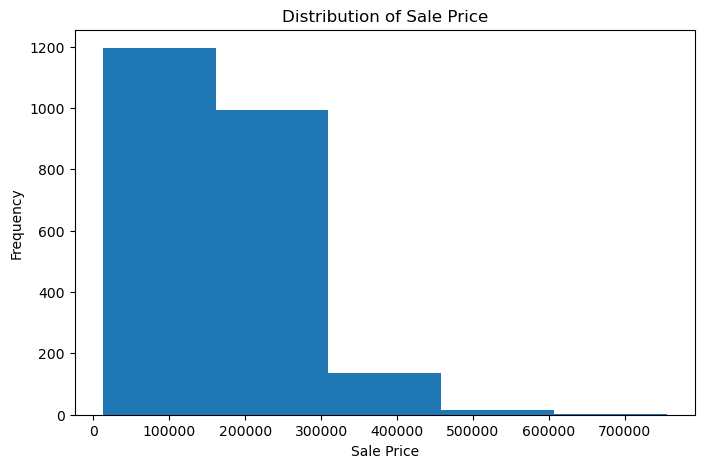

In [21]:
plt.figure(figsize=(8,5))
plt.hist(y_train, bins=5)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

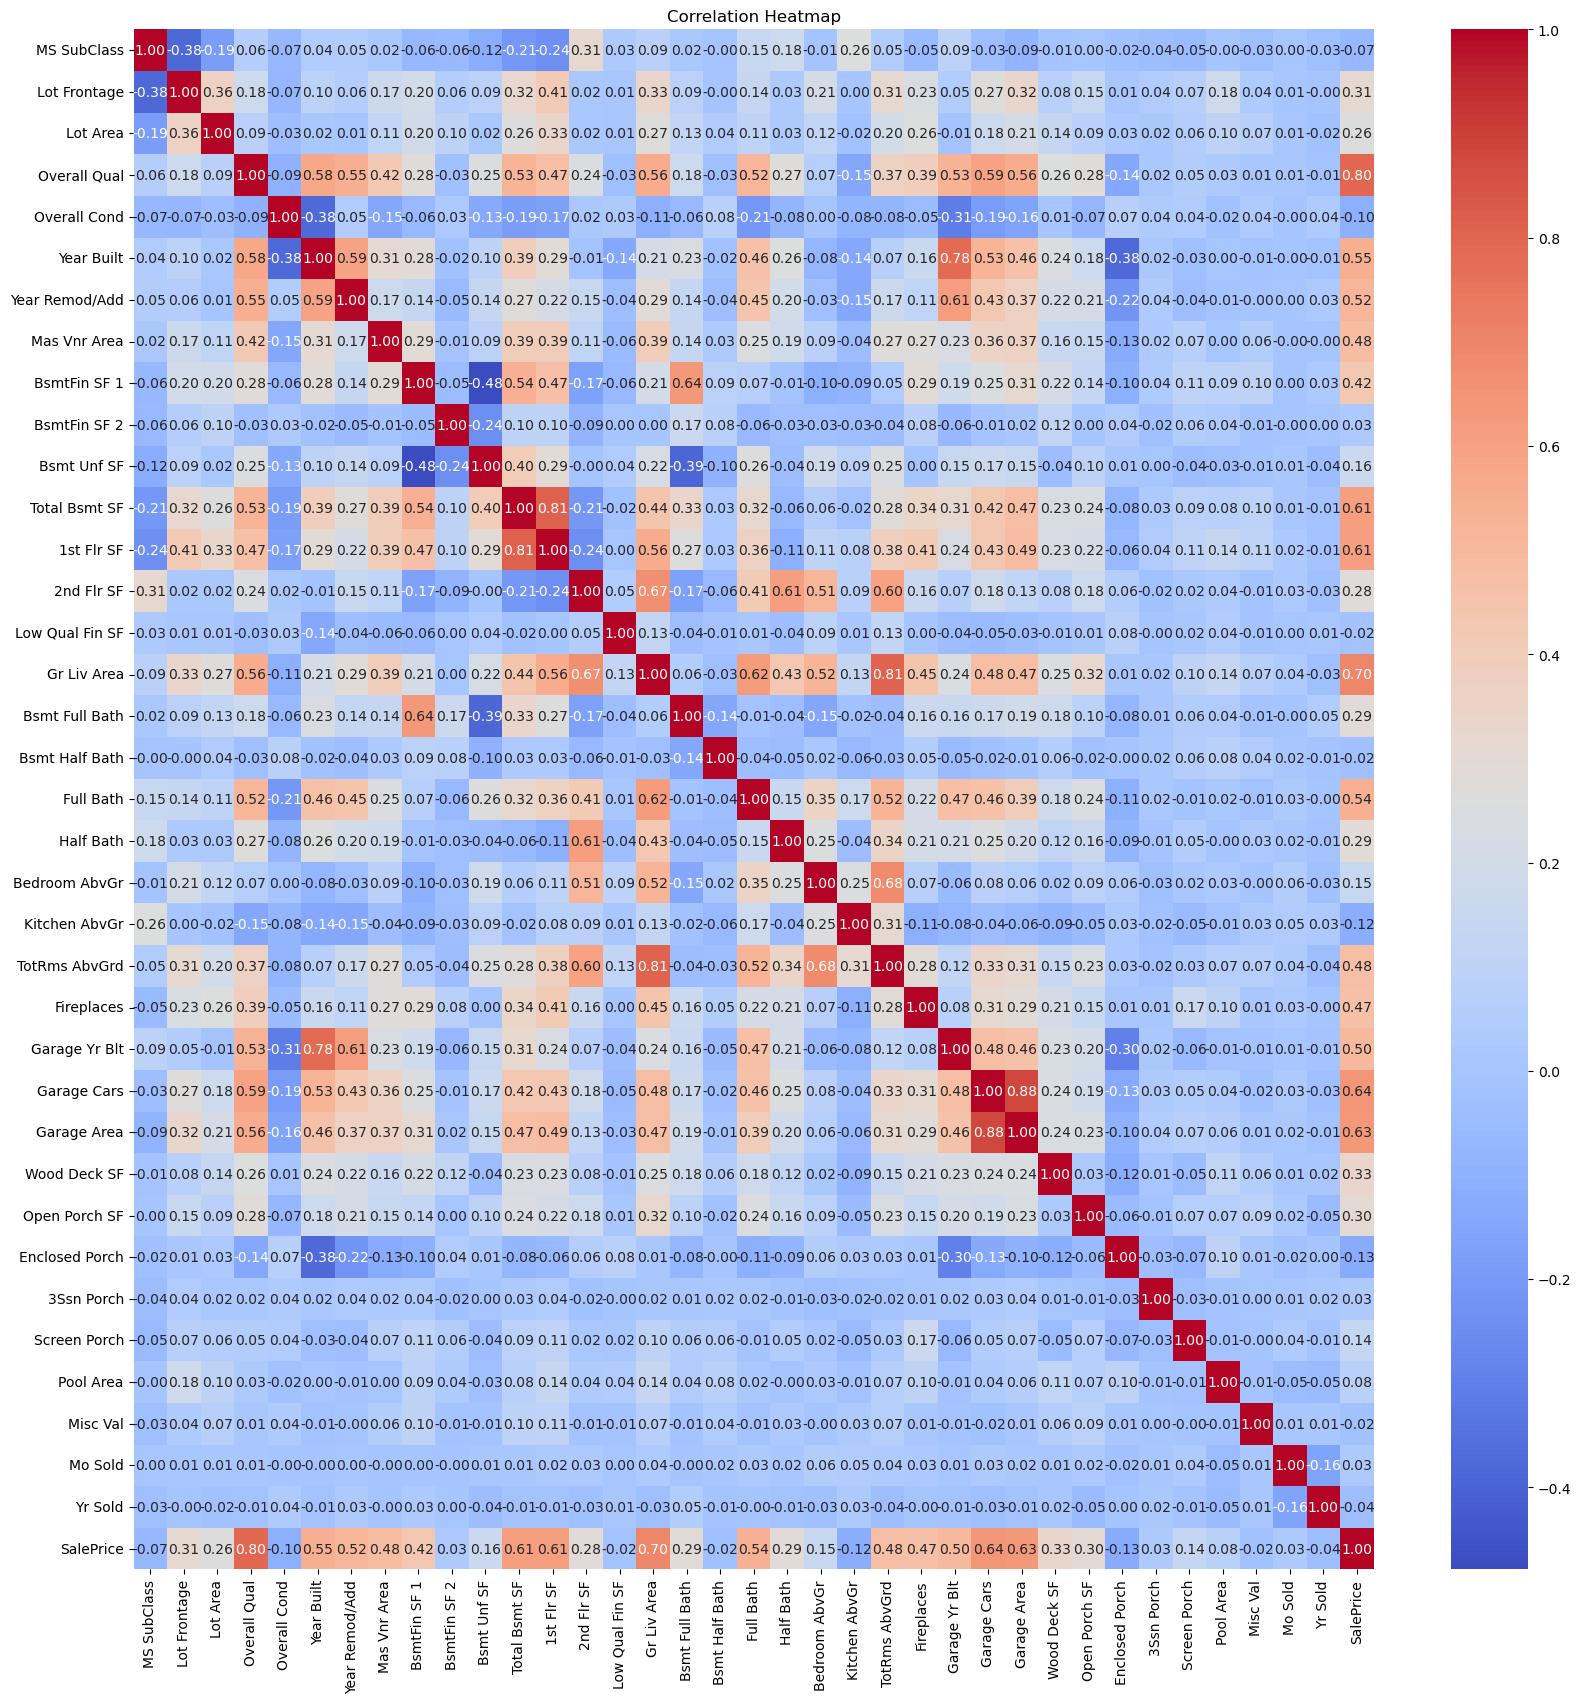

In [22]:
numeric_df = X_train.select_dtypes(include=["int64","float64"]).copy()
numeric_df["SalePrice"] = y_train.values
plt.figure(figsize=(20,20))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [23]:
corr = numeric_df.corr()
print(corr["SalePrice"].sort_values(ascending=False))

SalePrice          1.000000
Overall Qual       0.795298
Gr Liv Area        0.698315
Garage Cars        0.644218
Garage Area        0.633084
Total Bsmt SF      0.612110
1st Flr SF         0.607433
Year Built         0.545409
Full Bath          0.542053
Year Remod/Add     0.517653
Garage Yr Blt      0.499366
Mas Vnr Area       0.484157
TotRms AbvGrd      0.475455
Fireplaces         0.467501
BsmtFin SF 1       0.423835
Wood Deck SF       0.333045
Lot Frontage       0.310803
Open Porch SF      0.297722
Bsmt Full Bath     0.286825
Half Bath          0.285369
2nd Flr SF         0.278977
Lot Area           0.261336
Bsmt Unf SF        0.163629
Bedroom AbvGr      0.149269
Screen Porch       0.136936
Pool Area          0.079020
3Ssn Porch         0.034845
Mo Sold            0.030714
BsmtFin SF 2       0.027357
Low Qual Fin SF   -0.016025
Misc Val          -0.017729
Bsmt Half Bath    -0.023531
Yr Sold           -0.037686
MS SubClass       -0.066351
Overall Cond      -0.104085
Kitchen AbvGr     -0

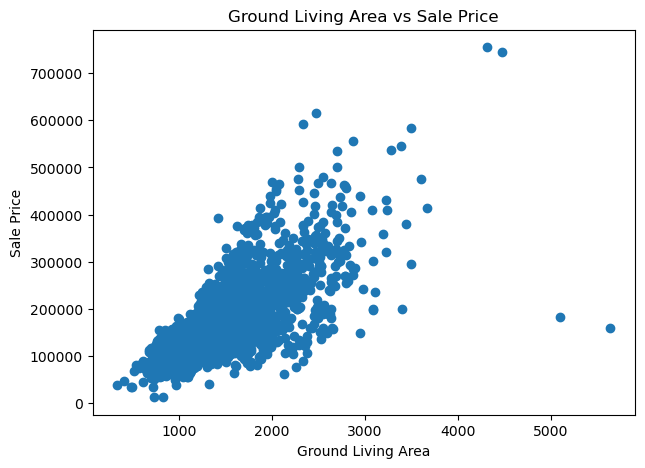

In [24]:
plt.figure(figsize=(7,5))
plt.scatter(X_train["Gr Liv Area"], y_train)
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Ground Living Area vs Sale Price")
plt.show()

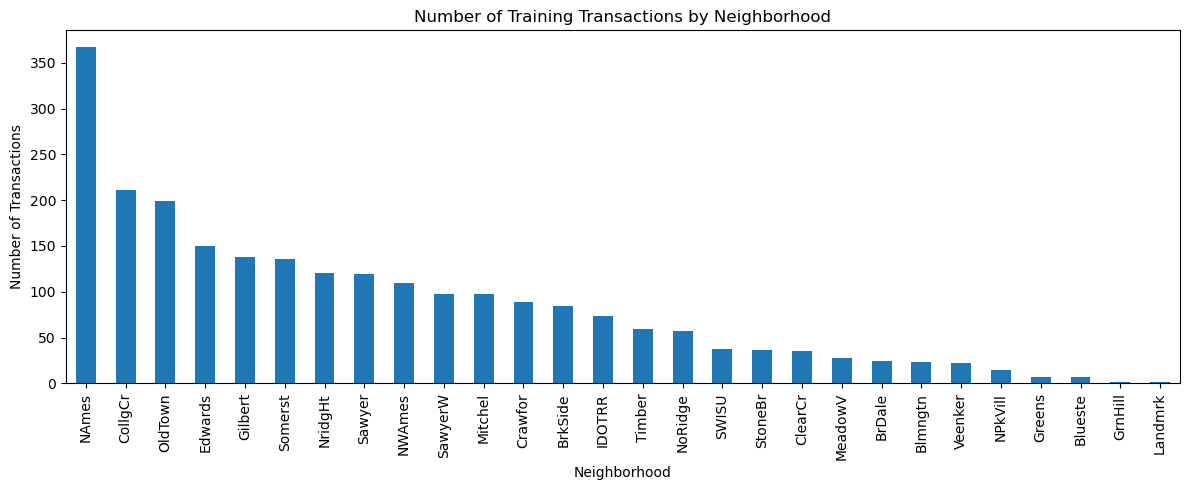

In [25]:
# Categorical distribution neighbourhood transaction counts in the training data
neighbourhood_counts = X_train["Neighborhood"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
neighbourhood_counts.plot(kind="bar")
plt.title("Number of Training Transactions by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

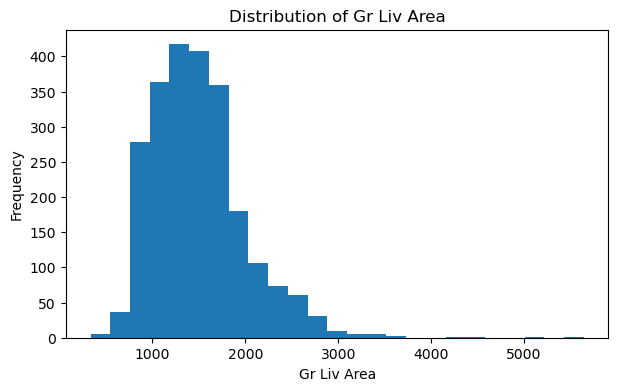

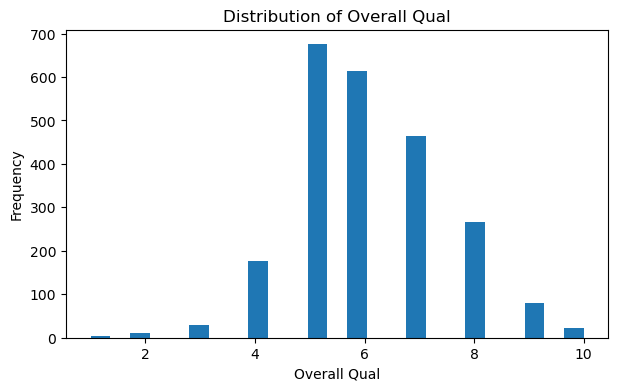

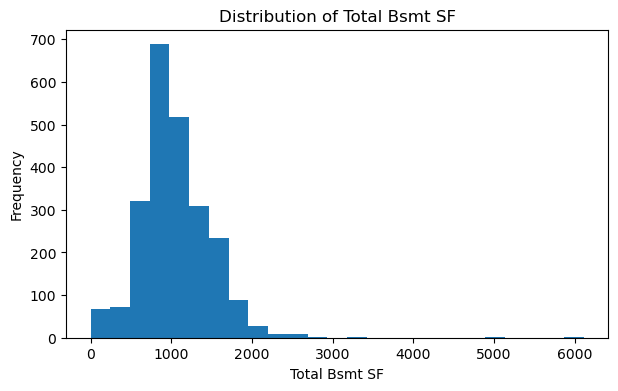

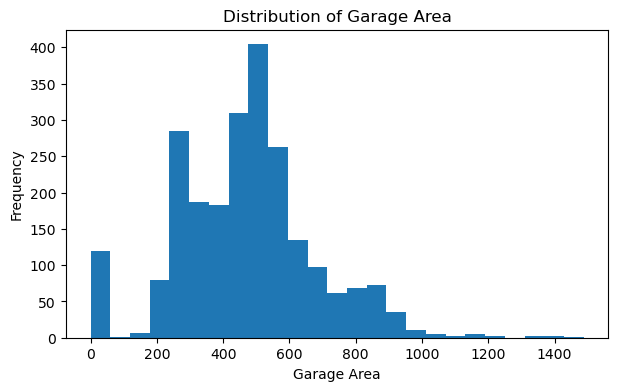

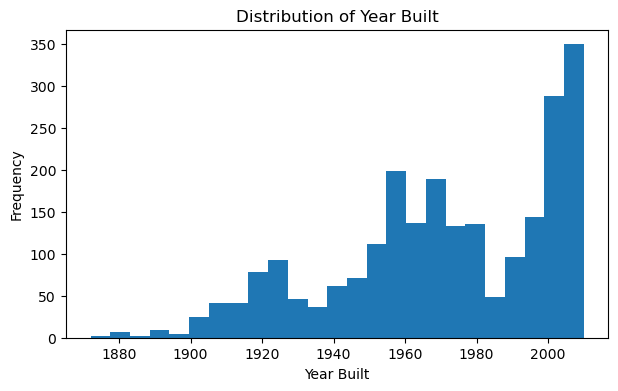

In [26]:
# Distribution of selected important numeric predictors
eda_numeric_columns = [
    "Gr Liv Area",
    "Overall Qual",
    "Total Bsmt SF",
    "Garage Area",
    "Year Built"
]

for column in eda_numeric_columns:
    if column in X_train.columns:
        plt.figure(figsize=(7, 4))
        plt.hist(X_train[column].dropna(), bins=25)
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.show()

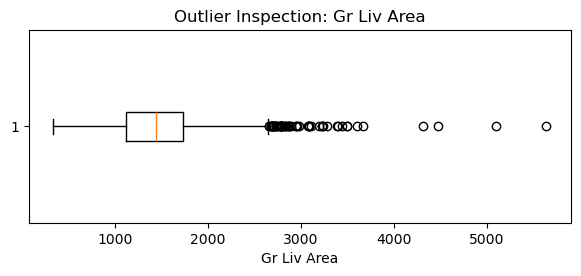

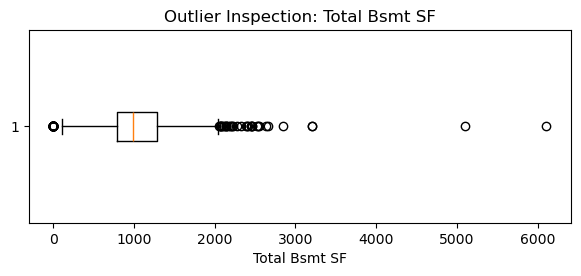

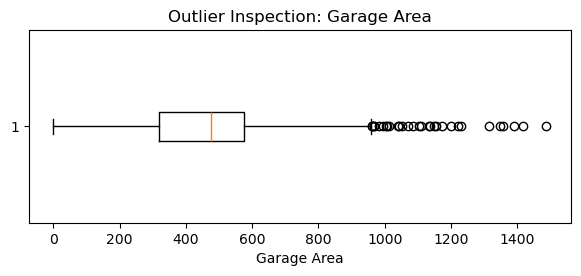

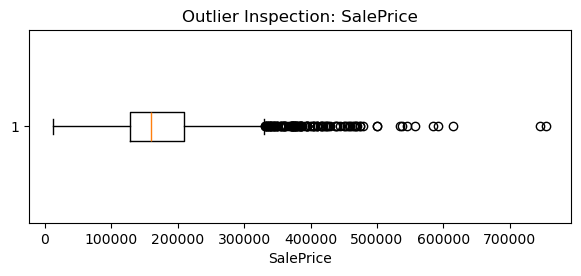

In [27]:
# Boxplots for potential outliers in important continuous variables
outlier_columns = [
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Area"
]

for column in outlier_columns:
    if column in X_train.columns:
        plt.figure(figsize=(7, 2.5))
        plt.boxplot(X_train[column].dropna(), vert=False)
        plt.title(f"Outlier Inspection: {column}")
        plt.xlabel(column)
        plt.show()

plt.figure(figsize=(7, 2.5))
plt.boxplot(y_train.dropna(), vert=False)
plt.title("Outlier Inspection: SalePrice")
plt.xlabel("SalePrice")
plt.show()

In [28]:
# IQR based outlier counts for review only
def iqr_outlier_summary(series):
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((clean < lower) | (clean > upper)).sum()
    return pd.Series({
        "Q1": q1,
        "Q3": q3,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Flagged Observations": int(count)
    })

outlier_summary = pd.DataFrame({
    column: iqr_outlier_summary(X_train[column])
    for column in outlier_columns
    if column in X_train.columns
}).T

outlier_summary.loc["SalePrice"] = iqr_outlier_summary(y_train)
outlier_summary

,Q1,Q3,Lower Bound,Upper Bound,Flagged Observations
Gr Liv Area,1121.75,1734.0,203.375,2652.375,59.0
Total Bsmt SF,784.00,1288.0,28.000,2044.000,94.0
Garage Area,319.00,576.0,-66.500,961.500,30.0
SalePrice,129000.00,210000.0,7500.000,331500.000,107.0


# Train-test split

In [29]:
X_train_baseline = X_train.copy()
X_test_baseline = X_test.copy()

# Create neighbourhood features

In [30]:
neighbourhood_statistics = pd.DataFrame({
    "Neighborhood": X_train["Neighborhood"].values,
    "SalePrice": y_train.values
})

In [31]:
neighbourhood_sum = (
    neighbourhood_statistics
    .groupby("Neighborhood")["SalePrice"]
    .transform("sum")
)

neighbourhood_count = (
    neighbourhood_statistics
    .groupby("Neighborhood")["SalePrice"]
    .transform("count")
)

global_saleprice_mean = y_train.mean()

X_train_neighbourhood = X_train.copy()

X_train_neighbourhood[
    "Neighbourhood_Avg_SalePrice"
] = np.where(
    neighbourhood_count > 1,
    (
        neighbourhood_sum - y_train.values
    ) /
    (
        neighbourhood_count - 1
    ),
    global_saleprice_mean
)

## Calculate neighbourhood average for test data

In [32]:
neighbourhood_mean = (
    neighbourhood_statistics
    .groupby("Neighborhood")["SalePrice"]
    .mean()
)

X_test_neighbourhood = X_test.copy()

X_test_neighbourhood[
    "Neighbourhood_Avg_SalePrice"
] = (
    X_test_neighbourhood["Neighborhood"]
    .map(neighbourhood_mean)
    .fillna(global_saleprice_mean)
)

# Transaction frequency

In [33]:
transaction_frequency = (
    X_train["Neighborhood"]
    .value_counts()
)

X_train_neighbourhood[
    "Transaction_Frequency"
] = (
    X_train_neighbourhood["Neighborhood"]
    .map(transaction_frequency)
    .fillna(0)
)

X_test_neighbourhood[
    "Transaction_Frequency"
] = (
    X_test_neighbourhood["Neighborhood"]
    .map(transaction_frequency)
    .fillna(0)
)

# Neighbourhood Demand Index

In [34]:
total_training_transactions = len(X_train)

neighbourhood_demand_index = (
    transaction_frequency /
    total_training_transactions
) * 100

X_train_neighbourhood[
    "Neighbourhood_Demand_Index"
] = (
    X_train_neighbourhood["Neighborhood"]
    .map(neighbourhood_demand_index)
    .fillna(0)
)

X_test_neighbourhood[
    "Neighbourhood_Demand_Index"
] = (
    X_test_neighbourhood["Neighborhood"]
    .map(neighbourhood_demand_index)
    .fillna(0)
)

## Average neighbourhood living area

In [35]:
neighbourhood_avg_living_area = (
    X_train.join(y_train)
    .groupby("Neighborhood")["Gr Liv Area"]
    .mean()
)

X_train_neighbourhood[
    "Neighbourhood_Avg_Living_Area"
] = (
    X_train_neighbourhood["Neighborhood"]
    .map(neighbourhood_avg_living_area)
)

X_test_neighbourhood[
    "Neighbourhood_Avg_Living_Area"
] = (
    X_test_neighbourhood["Neighborhood"]
    .map(neighbourhood_avg_living_area)
    .fillna(X_train["Gr Liv Area"].mean())
)

## Average neighbourhood house quality

In [36]:
neighbourhood_avg_quality = (
    X_train.join(y_train)
    .groupby("Neighborhood")["Overall Qual"]
    .mean()
)

X_train_neighbourhood[
    "Neighbourhood_Avg_Quality"
] = (
    X_train_neighbourhood["Neighborhood"]
    .map(neighbourhood_avg_quality)
)

X_test_neighbourhood[
    "Neighbourhood_Avg_Quality"
] = (
    X_test_neighbourhood["Neighborhood"]
    .map(neighbourhood_avg_quality)
    .fillna(X_train["Overall Qual"].mean())
)

# Neighbourhood short codes to real naam

In [37]:
# Real full names of the 28 Ames Housing neighbourhood codes
# (source: De Cock, 2011 - Ames Housing dataset documentation)
neighbourhood_place_names = {
    "Blmngtn": "Bloomington Heights",
    "Blueste": "Bluestem",
    "BrDale": "Briardale",
    "BrkSide": "Brookside",
    "ClearCr": "Clear Creek",
    "CollgCr": "College Creek",
    "Crawfor": "Crawford",
    "Edwards": "Edwards",
    "Gilbert": "Gilbert",
    "Greens": "Greens",
    "GrnHill": "Green Hills",
    "IDOTRR": "Iowa DOT and Rail Road",
    "Landmrk": "Landmark",
    "MeadowV": "Meadow Village",
    "Mitchel": "Mitchell",
    "NAmes": "North Ames",
    "NoRidge": "Northridge",
    "NPkVill": "Northpark Villa",
    "NridgHt": "Northridge Heights",
    "NWAmes": "Northwest Ames",
    "OldTown": "Old Town",
    "SWISU": "South and West of Iowa State University",
    "Sawyer": "Sawyer",
    "SawyerW": "Sawyer West",
    "Somerst": "Somerset",
    "StoneBr": "Stone Brook",
    "Timber": "Timberland",
    "Veenker": "Veenker",
}
# Add known OSM name variants from the Ames Housing dataset.
# These variants are tried before using the fallback.
known_osm_aliases = {
    "StoneBr": [
        "Stone Brooke, Ames, Iowa, USA",
        "Stone Brooke Road, Ames, Iowa, USA",
    ],
    "SWISU": [
        "Iowa State University, Ames, Iowa, USA",
    ],
    "IDOTRR": [
        "Iowa Department of Transportation, Ames, Iowa, USA",
    ],
}

# Query variants builder + geocoding function

In [38]:
AMES_CITY_CENTER = (42.0308, -93.6319)

def build_query_variants(code_name, place_name):
    variants = [
        f"{place_name}, Ames, Iowa, USA",
        f"{place_name} neighborhood, Ames, Iowa, USA",
        f"{place_name}, Ames, IA",
        f"{place_name}, Story County, Iowa, USA",
        f"{place_name}, Iowa, USA",
    ]
    # Try any known OSM-specific spellings for this code before giving up
    variants = (
        known_osm_aliases.get(code_name, [])
        + variants
    )
    return variants


def geocode_place_multi(
    code_name,
    place_name,
    fallback=AMES_CITY_CENTER,
):
    for query in build_query_variants(code_name, place_name):
        try:
            lat, lon = ox.geocode(query)
            return (lat, lon)
        except Exception:
            continue

    print(
        f"Could not geocode '{place_name}' ({code_name}) "
        "with any variant -> using Ames city-centre fallback."
    )
    return fallback

# Neighbourhood coordinates geocode

In [39]:
neighbourhood_coords = {}

for code_name, place_name in neighbourhood_place_names.items():
    neighbourhood_coords[code_name] = (
        geocode_place_multi(code_name, place_name)
    )
    time.sleep(1)  # be polite to the free geocoding service, avoid getting rate-limited

neighbourhood_coords

Could not geocode 'Northpark Villa' (NPkVill) with any variant -> using Ames city-centre fallback.
Could not geocode 'Sawyer West' (SawyerW) with any variant -> using Ames city-centre fallback.


{'Blmngtn': (42.0600876, -93.6391964),
 'Blueste': (42.0111554, -93.6450688),
 'BrDale': (42.052277, -93.6283726),
 'BrkSide': (42.03051, -93.6320237),
 'ClearCr': (42.0298707, -93.659696),
 'CollgCr': (42.0254297, -93.6320782),
 'Crawfor': (42.0183748, -93.6489526),
 'Edwards': (42.0159015, -93.6855863),
 'Gilbert': (42.1069288, -93.6496628),
 'Greens': (41.5105069, -93.6642602),
 'GrnHill': (42.0020471, -93.6465898),
 'IDOTRR': (42.0197469, -93.622168),
 'Landmrk': (42.0178463, -93.4427347),
 'MeadowV': (41.5710685, -95.8696668),
 'Mitchel': (41.9905843, -93.601258),
 'NAmes': (42.0496061, -93.6218746),
 'NoRidge': (42.0598105, -93.6547903),
 'NPkVill': (42.0308, -93.6319),
 'NridgHt': (42.0598105, -93.6547903),
 'NWAmes': (42.0145311, -93.6369891),
 'OldTown': (42.0295168, -93.6137815),
 'SWISU': (42.0279608, -93.6447375),
 'Sawyer': (42.0339239, -93.6766484),
 'SawyerW': (42.0308, -93.6319),
 'Somerst': (42.0495865, -93.645204),
 'StoneBr': (42.0591745, -93.6327299),
 'Timber': (41

# Amenities geocode

In [40]:
amenities = {
    "Iowa State University": "Iowa State University, Ames, Iowa, USA",
    "Downtown Ames": "Downtown Ames, Ames, Iowa, USA",
    "Mary Greeley Medical Center": "Mary Greeley Medical Center, Ames, Iowa, USA",
    "North Grand Mall": "North Grand Mall, Ames, Iowa, USA",
}

amenity_coords = {}

for name, query in amenities.items():
    try:
        amenity_coords[name] = ox.geocode(query)
    except Exception:
        print(f"Could not geocode amenity '{name}' -> using Ames city-centre fallback.")
        amenity_coords[name] = AMES_CITY_CENTER
    time.sleep(1)

amenity_coords

{'Iowa State University': (42.0279608, -93.6447375),
 'Downtown Ames': (42.0262365, -93.6160867),
 'Mary Greeley Medical Center': (42.0326163, -93.6122883),
 'North Grand Mall': (42.0496061, -93.6218746)}

# Transparency check

In [41]:
fallback_used = [
    code_name
    for code_name, coords in neighbourhood_coords.items()
    if coords == AMES_CITY_CENTER
]

print(
    f"{len(neighbourhood_coords) - len(fallback_used)} / "
    f"{len(neighbourhood_coords)} neighbourhoods geocoded successfully."
)
print("Neighbourhoods using the city-centre fallback:", fallback_used)

26 / 28 neighbourhoods geocoded successfully.
Neighbourhoods using the city-centre fallback: ['NPkVill', 'SawyerW']


# Road network download

In [42]:
G = (
    ox.graph_from_place("Ames, Iowa, USA", network_type="drive")
)
G = ox.add_edge_speeds(G)

# REAL FIX: fakt sauthi motu, fully-connected part rakho
# Aa thi koi j "No path" error nahi aave - badha remaining nodes vachche guaranteed rasto hoy
G = ox.truncate.largest_component(G, strongly=True)

print(
    "Road network loaded:",
    len(G.nodes), "nodes,",
    len(G.edges), "edges",
)

Road network loaded: 1841 nodes, 5140 edges


# Nearest road-nodes

In [43]:
def nearest_node(lat, lon):
    return ox.distance.nearest_nodes(G, lon, lat)


neighbourhood_nodes = {
    code_name: nearest_node(lat, lon)
    for code_name, (lat, lon) in neighbourhood_coords.items()
}

amenity_nodes = {
    name: nearest_node(lat, lon)
    for name, (lat, lon) in amenity_coords.items()
}

# Distance

In [44]:
distance_records = []

for code_name, n_node in neighbourhood_nodes.items():
    row = {"Neighborhood": code_name}
    total_dist = 0

    for amenity_name, a_node in amenity_nodes.items():
        dist_m = nx.shortest_path_length(G, n_node, a_node, weight="length")
        total_dist += dist_m / 1000   # km

    row["Total_Distance_km"] = total_dist
    distance_records.append(row)

road_network_features = pd.DataFrame(distance_records)
road_network_features

,Neighborhood,Total_Distance_km
0,Blmngtn,16.579384
1,Blueste,18.768591
2,BrDale,11.935700
3,BrkSide,8.980993
4,ClearCr,16.363287
5,CollgCr,10.191570
6,Crawfor,15.582127
7,Edwards,28.413766
8,Gilbert,24.648698
9,Greens,27.412218


# Merge

In [45]:
X_train_neighbourhood = X_train_neighbourhood.merge(road_network_features, on="Neighborhood", how="left")
X_test_neighbourhood = X_test_neighbourhood.merge(road_network_features, on="Neighborhood", how="left")

X_train_neighbourhood[["Neighborhood", "Total_Distance_km"]].head(10)

,Neighborhood,Total_Distance_km
0,NWAmes,13.123978
1,ClearCr,16.363287
2,NAmes,9.506342
3,NAmes,9.506342
4,OldTown,6.876574
5,ClearCr,16.363287
6,NoRidge,20.024200
7,NAmes,9.506342
8,NAmes,9.506342
9,CollgCr,10.191570


### Check neighbourhood features

In [46]:
X_train_neighbourhood[
    [
        "Neighborhood",
        "Neighbourhood_Avg_SalePrice",
        "Transaction_Frequency",
        "Neighbourhood_Demand_Index",
        "Neighbourhood_Avg_Living_Area",
        "Neighbourhood_Avg_Quality",
        "Total_Distance_km"
    ]
].head(10)

,Neighborhood,Neighbourhood_Avg_SalePrice,Transaction_Frequency,Neighbourhood_Demand_Index,Neighbourhood_Avg_Living_Area,Neighbourhood_Avg_Quality,Total_Distance_km
0,NWAmes,186397.731481,109,4.650171,1678.211009,6.321101,13.123978
1,ClearCr,211356.823529,35,1.493174,1751.771429,6.028571,16.363287
2,NAmes,145744.579235,367,15.656997,1287.253406,5.359673,9.506342
3,NAmes,145776.819672,367,15.656997,1287.253406,5.359673,9.506342
4,OldTown,124909.045455,199,8.489761,1469.301508,5.211055,6.876574
5,ClearCr,210592.117647,35,1.493174,1751.771429,6.028571,16.363287
6,NoRidge,331668.000000,57,2.431741,2498.578947,7.964912,20.024200
7,NAmes,145640.207650,367,15.656997,1287.253406,5.359673,9.506342
8,NAmes,145670.262295,367,15.656997,1287.253406,5.359673,9.506342
9,CollgCr,200405.042857,211,9.001706,1478.511848,6.654028,10.191570


# Create mortgage-rate dataset

In [47]:
mortgage_url = (
    "https://fred.stlouisfed.org/graph/"
    "fredgraph.csv?id=MORTGAGE30US"
)

mortgage = pd.read_csv(mortgage_url)

# Check the downloaded columns
print("Mortgage dataset columns:")
print(mortgage.columns.tolist())

mortgage.head()

Mortgage dataset columns:
['observation_date', 'MORTGAGE30US']


,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [48]:
mortgage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2895 entries, 0 to 2894
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  2895 non-null   object 
 1   MORTGAGE30US      2895 non-null   float64
dtypes: float64(1), object(1)
memory usage: 45.4+ KB


In [49]:
# Convert columns to correct data types
mortgage["observation_date"] = pd.to_datetime(mortgage["observation_date"], errors="coerce")

In [50]:
# Remove invalid rows
mortgage = mortgage.dropna(subset=["observation_date", "MORTGAGE30US"])

In [51]:
# Extract year and month
mortgage["Yr Sold"] = mortgage["observation_date"].dt.year
mortgage["Mo Sold"] = mortgage["observation_date"].dt.month

In [52]:
monthly_mortgage = (
    mortgage
    .groupby(
        ["Yr Sold", "Mo Sold"]
    )["MORTGAGE30US"]
    .mean()
    .reset_index()
)

monthly_mortgage = monthly_mortgage.rename(
    columns={
        "MORTGAGE30US": "MortgageRate"
    }
)

In [53]:
monthly_mortgage.head()

,Yr Sold,Mo Sold,MortgageRate
0,1971,4,7.3100
1,1971,5,7.4250
2,1971,6,7.5300
3,1971,7,7.6040
4,1971,8,7.6975


In [54]:
print(
    monthly_mortgage[
        monthly_mortgage["Yr Sold"].between(2006, 2010)
    ]
)

     Yr Sold  Mo Sold  MortgageRate
417     2006        1        6.1450
418     2006        2        6.2525
419     2006        3        6.3240
420     2006        4        6.5075
421     2006        5        6.5975
422     2006        6        6.6820
423     2006        7        6.7625
424     2006        8        6.5240
425     2006        9        6.4025
426     2006       10        6.3575
427     2006       11        6.2400
428     2006       12        6.1350
429     2007        1        6.2175
430     2007        2        6.2850
431     2007        3        6.1560
432     2007        4        6.1800
433     2007        5        6.2620
434     2007        6        6.6575
435     2007        7        6.6950
436     2007        8        6.5720
437     2007        9        6.3825
438     2007       10        6.3750
439     2007       11        6.2080
440     2007       12        6.0950
441     2008        1        5.7580
442     2008        2        5.9175
443     2008        3       

In [55]:
X_train_mortgage = X_train.copy()
X_test_mortgage = X_test.copy()

In [56]:
X_train_mortgage = X_train_mortgage.merge(
    monthly_mortgage,
    on=["Yr Sold", "Mo Sold"],
    how="left"
)

X_test_mortgage = X_test_mortgage.merge(
    monthly_mortgage,
    on=["Yr Sold", "Mo Sold"],
    how="left"
)

# Create engineered features

In [57]:
X_train_all = X_train_neighbourhood.copy()
X_test_all = X_test_neighbourhood.copy()

In [58]:
X_train_all["TotalSF"] = (
    X_train_all["Total Bsmt SF"]
    + X_train_all["1st Flr SF"]
    + X_train_all["2nd Flr SF"]
)

X_test_all["TotalSF"] = (
    X_test_all["Total Bsmt SF"]
    + X_test_all["1st Flr SF"]
    + X_test_all["2nd Flr SF"]
)

In [59]:
X_train_all["TotalBath"] = (
    X_train_all["Full Bath"]
    + 0.5 * X_train_all["Half Bath"]
    + X_train_all["Bsmt Full Bath"]
    + 0.5 * X_train_all["Bsmt Half Bath"]
)

X_test_all["TotalBath"] = (
    X_test_all["Full Bath"]
    + 0.5 * X_test_all["Half Bath"]
    + X_test_all["Bsmt Full Bath"]
    + 0.5 * X_test_all["Bsmt Half Bath"]
)

In [60]:
X_train_all["TotalPorchSF"] = (
    X_train_all["Open Porch SF"]
    + X_train_all["Enclosed Porch"]
    + X_train_all["3Ssn Porch"]
    + X_train_all["Screen Porch"]
    + X_train_all["Wood Deck SF"]
)

X_test_all["TotalPorchSF"] = (
    X_test_all["Open Porch SF"]
    + X_test_all["Enclosed Porch"]
    + X_test_all["3Ssn Porch"]
    + X_test_all["Screen Porch"]
    + X_test_all["Wood Deck SF"]
)

In [61]:
X_train_all["HouseAge"] = (
    X_train_all["Yr Sold"]
    - X_train_all["Year Built"]
)

X_test_all["HouseAge"] = (
    X_test_all["Yr Sold"]
    - X_test_all["Year Built"]
)

In [62]:
X_train_all["RemodAge"] = (
    X_train_all["Yr Sold"]
    - X_train_all["Year Remod/Add"]
)

X_test_all["RemodAge"] = (
    X_test_all["Yr Sold"]
    - X_test_all["Year Remod/Add"]
)

In [63]:
X_train_all["TotalBsmtFinSF"] = (
    X_train_all["BsmtFin SF 1"]
    + X_train_all["BsmtFin SF 2"]
)

X_test_all["TotalBsmtFinSF"] = (
    X_test_all["BsmtFin SF 1"]
    + X_test_all["BsmtFin SF 2"]
)

# Add mortgage rate to ALL engineered features

In [64]:
X_train_all = X_train_all.merge(
    monthly_mortgage,
    on=["Yr Sold", "Mo Sold"],
    how="left"
)

X_test_all = X_test_all.merge(
    monthly_mortgage,
    on=["Yr Sold", "Mo Sold"],
    how="left"
)

In [65]:
engineered_columns = [
    "TotalSF",
    "TotalBath",
    "TotalPorchSF",
    "HouseAge",
    "RemodAge",
    "TotalBsmtFinSF",
    "Neighbourhood_Avg_SalePrice",
    "Transaction_Frequency",
    "Neighbourhood_Demand_Index",
    "Neighbourhood_Avg_Living_Area",
    "Neighbourhood_Avg_Quality",
    "Total_Distance_km",
    "MortgageRate"
]

X_train_all[
    engineered_columns
].head()

,TotalSF,TotalBath,TotalPorchSF,HouseAge,RemodAge,TotalBsmtFinSF,Neighbourhood_Avg_SalePrice,Transaction_Frequency,Neighbourhood_Demand_Index,Neighbourhood_Avg_Living_Area,Neighbourhood_Avg_Quality,Total_Distance_km,MortgageRate
0,2460.0,2.0,0,33,33,0.0,186397.731481,109,4.650171,1678.211009,6.321101,13.123978,5.420
1,3139.0,3.0,711,42,42,1013.0,211356.823529,35,1.493174,1751.771429,6.028571,16.363287,5.420
2,1224.0,2.0,0,45,45,0.0,145744.579235,367,15.656997,1287.253406,5.359673,9.506342,6.156
3,1040.0,2.0,0,60,59,0.0,145776.819672,367,15.656997,1287.253406,5.359673,9.506342,5.420
4,2301.0,2.0,148,89,59,0.0,124909.045455,199,8.489761,1469.301508,5.211055,6.876574,4.952


In [66]:
# chack NAN
print("MortgageRate NaN count:", X_train_all["MortgageRate"].isnull().sum())
print("Total_Distance_km NaN count:", X_train_all["Total_Distance_km"].isnull().sum())

MortgageRate NaN count: 0
Total_Distance_km NaN count: 0


# Baseline preprocessing

In [67]:
baseline_numeric = X_train_baseline.select_dtypes(
    include=np.number
).columns.tolist()

baseline_categorical = X_train_baseline.select_dtypes(
    include=["object"]
).columns.tolist()

baseline_preprocessor = ColumnTransformer(
    transformers=[
        (
          "numeric",
            SimpleImputer(strategy="median"),
            baseline_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            baseline_categorical
        )
    ]
)

# Define models

In [68]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        verbose=False,
        random_seed=42
    )
}

# BASELINE models

In [69]:
baseline_results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                baseline_preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train_baseline,
        y_train
    )

    predictions = pipeline.predict(
        X_test_baseline
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mape = (
        mean_absolute_percentage_error(
            y_test,
            predictions
        ) * 100
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    baseline_results.append({
        "Feature Set": "Original Baseline",
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2
    })

In [70]:
baseline_results = pd.DataFrame(
    baseline_results
)

In [71]:
baseline_results

,Feature Set,Model,RMSE,MAE,MAPE (%),R2
0,Original Baseline,Linear Regression,29205.264364,16390.931686,9.234951,0.893615
1,Original Baseline,Random Forest,26683.613234,15670.017941,8.472704,0.911193
2,Original Baseline,Gradient Boosting,24526.278083,14558.398180,7.778162,0.924972
3,Original Baseline,XGBoost,23582.811368,13794.000000,7.297058,0.930634
4,Original Baseline,CatBoost,24007.276252,14286.486526,7.556340,0.928114


# ORIGINAL + NEIGHBOURHOOD

In [72]:
neighbourhood_numeric = X_train_neighbourhood.select_dtypes(
    include=np.number
).columns.tolist()

neighbourhood_categorical = X_train_neighbourhood.select_dtypes(
    include=["object"]
).columns.tolist()

neighbourhood_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            neighbourhood_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            neighbourhood_categorical
        )
    ]
)

In [73]:
neighbourhood_results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                neighbourhood_preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train_neighbourhood,
        y_train
    )

    predictions = pipeline.predict(
        X_test_neighbourhood
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mape = (
        mean_absolute_percentage_error(
            y_test,
            predictions
        ) * 100
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    neighbourhood_results.append({
        "Feature Set": "Original + Neighbourhood",
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2
    })

In [74]:
neighbourhood_results = pd.DataFrame(
    neighbourhood_results
)

In [75]:
neighbourhood_results

,Feature Set,Model,RMSE,MAE,MAPE (%),R2
0,Original + Neighbourhood,Linear Regression,29113.608479,16284.668040,8.920120,0.894282
1,Original + Neighbourhood,Random Forest,26480.254832,15791.936416,8.557310,0.912541
2,Original + Neighbourhood,Gradient Boosting,24648.035928,14419.479433,7.760643,0.924226
3,Original + Neighbourhood,XGBoost,22571.854332,13261.304688,6.980920,0.936453
4,Original + Neighbourhood,CatBoost,21475.846429,13686.626520,7.300077,0.942475


# ORIGINAL + MORTGAGE

In [76]:
mortgage_numeric = X_train_mortgage.select_dtypes(
    include=np.number
).columns.tolist()

mortgage_categorical = X_train_mortgage.select_dtypes(
    include=["object"]
).columns.tolist()

mortgage_preprocessor = ColumnTransformer(
    transformers=[
        (
           "numeric",
            SimpleImputer(strategy="median"),
            mortgage_numeric
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            mortgage_categorical
        )
    ]
)

In [77]:
mortgage_results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                mortgage_preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train_mortgage,
        y_train
    )

    predictions = pipeline.predict(
        X_test_mortgage
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mape = (
        mean_absolute_percentage_error(
            y_test,
            predictions
        ) * 100
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    mortgage_results.append({
        "Feature Set": "Original + Mortgage Rate",
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2
    })

In [78]:
mortgage_results = pd.DataFrame(
    mortgage_results
)

In [79]:
mortgage_results

,Feature Set,Model,RMSE,MAE,MAPE (%),R2
0,Original + Mortgage Rate,Linear Regression,29228.398161,16385.592673,9.232103,0.893446
1,Original + Mortgage Rate,Random Forest,26572.923176,15723.919818,8.488781,0.911928
2,Original + Mortgage Rate,Gradient Boosting,25187.277147,14636.192232,7.803629,0.920874
3,Original + Mortgage Rate,XGBoost,24082.181961,13799.123047,7.269470,0.927665
4,Original + Mortgage Rate,CatBoost,23252.787895,14078.748304,7.502293,0.932561


# ORIGINAL + ALL ENGINEERED

In [80]:
all_numeric = X_train_all.select_dtypes(
    include=np.number
).columns.tolist()

all_categorical = X_train_all.select_dtypes(
    include=["object"]
).columns.tolist()

all_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            all_numeric
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            all_categorical
        )
    ]
)

In [81]:
all_results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                all_preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train_all,
        y_train
    )

    predictions = pipeline.predict(
        X_test_all
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    mape = (
        mean_absolute_percentage_error(
            y_test,
            predictions
        ) * 100
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    all_results.append({
        "Feature Set": "Original + All Engineered",
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE (%)": mape,
        "R2": r2
    })

In [82]:
all_results = pd.DataFrame(
    all_results
)

In [83]:
all_results

,Feature Set,Model,RMSE,MAE,MAPE (%),R2
0,Original + All Engineered,Linear Regression,29134.106244,16280.592118,8.919727,0.894133
1,Original + All Engineered,Random Forest,24654.286238,15119.910677,8.267517,0.924187
2,Original + All Engineered,Gradient Boosting,22647.665607,13877.648821,7.490018,0.936026
3,Original + All Engineered,XGBoost,22525.273272,13466.666992,7.128502,0.936715
4,Original + All Engineered,CatBoost,21208.939640,13402.130355,7.137441,0.943896


# Combine all four experiments

In [84]:
final_results = pd.concat(
    [
        baseline_results,
        neighbourhood_results,
        mortgage_results,
        all_results
    ],
    ignore_index=True
)

In [85]:
final_results

,Feature Set,Model,RMSE,MAE,MAPE (%),R2
0,Original Baseline,Linear Regression,29205.264364,16390.931686,9.234951,0.893615
1,Original Baseline,Random Forest,26683.613234,15670.017941,8.472704,0.911193
2,Original Baseline,Gradient Boosting,24526.278083,14558.398180,7.778162,0.924972
3,Original Baseline,XGBoost,23582.811368,13794.000000,7.297058,0.930634
4,Original Baseline,CatBoost,24007.276252,14286.486526,7.556340,0.928114
5,Original + Neighbourhood,Linear Regression,29113.608479,16284.668040,8.920120,0.894282
6,Original + Neighbourhood,Random Forest,26480.254832,15791.936416,8.557310,0.912541
7,Original + Neighbourhood,Gradient Boosting,24648.035928,14419.479433,7.760643,0.924226
8,Original + Neighbourhood,XGBoost,22571.854332,13261.304688,6.980920,0.936453
9,Original + Neighbourhood,CatBoost,21475.846429,13686.626520,7.300077,0.942475


In [86]:
final_results.sort_values(
    by="R2",
    ascending=False
)

,Feature Set,Model,RMSE,MAE,MAPE (%),R2
19,Original + All Engineered,CatBoost,21208.939640,13402.130355,7.137441,0.943896
9,Original + Neighbourhood,CatBoost,21475.846429,13686.626520,7.300077,0.942475
18,Original + All Engineered,XGBoost,22525.273272,13466.666992,7.128502,0.936715
8,Original + Neighbourhood,XGBoost,22571.854332,13261.304688,6.980920,0.936453
17,Original + All Engineered,Gradient Boosting,22647.665607,13877.648821,7.490018,0.936026
14,Original + Mortgage Rate,CatBoost,23252.787895,14078.748304,7.502293,0.932561
3,Original Baseline,XGBoost,23582.811368,13794.000000,7.297058,0.930634
4,Original Baseline,CatBoost,24007.276252,14286.486526,7.556340,0.928114
13,Original + Mortgage Rate,XGBoost,24082.181961,13799.123047,7.269470,0.927665
2,Original Baseline,Gradient Boosting,24526.278083,14558.398180,7.778162,0.924972


In [87]:
r2_comparison = final_results.pivot(
    index="Model",
    columns="Feature Set",
    values="R2"
)

r2_comparison

Feature Set,Original + All Engineered,Original + Mortgage Rate,Original + Neighbourhood,Original Baseline
Model,,,,
CatBoost,0.943896,0.932561,0.942475,0.928114
Gradient Boosting,0.936026,0.920874,0.924226,0.924972
Linear Regression,0.894133,0.893446,0.894282,0.893615
Random Forest,0.924187,0.911928,0.912541,0.911193
XGBoost,0.936715,0.927665,0.936453,0.930634


In [88]:
best_models = (
    final_results
    .sort_values(
        "R2",
        ascending=False
    )
    .groupby(
        "Feature Set"
    )
    .first()
    .reset_index()
)

# Find best model in each experiment

In [89]:
best_models

,Feature Set,Model,RMSE,MAE,MAPE (%),R2
0,Original + All Engineered,CatBoost,21208.939640,13402.130355,7.137441,0.943896
1,Original + Mortgage Rate,CatBoost,23252.787895,14078.748304,7.502293,0.932561
2,Original + Neighbourhood,CatBoost,21475.846429,13686.626520,7.300077,0.942475
3,Original Baseline,XGBoost,23582.811368,13794.000000,7.297058,0.930634


# Improvement over baseline

In [90]:
baseline_r2 = baseline_results[
    [
        "Model",
        "R2"
    ]
].rename(
    columns={
        "R2": "Baseline_R2"
    }
)

final_comparison = final_results.merge(
    baseline_r2,
    on="Model",
    how="left"
)

final_comparison[
    "R2_Improvement"
] = (
    final_comparison["R2"]
    - final_comparison["Baseline_R2"]
)

final_comparison[
    "R2_Improvement_Percentage"
] = (
    final_comparison["R2_Improvement"]
    / final_comparison["Baseline_R2"]
) * 100

In [91]:
final_comparison

,Feature Set,Model,RMSE,MAE,MAPE (%),R2,Baseline_R2,R2_Improvement,R2_Improvement_Percentage
0,Original Baseline,Linear Regression,29205.264364,16390.931686,9.234951,0.893615,0.893615,0.000000,0.000000
1,Original Baseline,Random Forest,26683.613234,15670.017941,8.472704,0.911193,0.911193,0.000000,0.000000
2,Original Baseline,Gradient Boosting,24526.278083,14558.398180,7.778162,0.924972,0.924972,0.000000,0.000000
3,Original Baseline,XGBoost,23582.811368,13794.000000,7.297058,0.930634,0.930634,0.000000,0.000000
4,Original Baseline,CatBoost,24007.276252,14286.486526,7.556340,0.928114,0.928114,0.000000,0.000000
5,Original + Neighbourhood,Linear Regression,29113.608479,16284.668040,8.920120,0.894282,0.893615,0.000667,0.074607
6,Original + Neighbourhood,Random Forest,26480.254832,15791.936416,8.557310,0.912541,0.911193,0.001348,0.147988
7,Original + Neighbourhood,Gradient Boosting,24648.035928,14419.479433,7.760643,0.924226,0.924972,-0.000747,-0.080736
8,Original + Neighbourhood,XGBoost,22571.854332,13261.304688,6.980920,0.936453,0.930634,0.005820,0.625359
9,Original + Neighbourhood,CatBoost,21475.846429,13686.626520,7.300077,0.942475,0.928114,0.014361,1.547296


# Hyperparameter tuning

In [92]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [93]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", all_preprocessor),
        ("model", XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

xgb_param_grid = {
    "model__n_estimators": [300, 500, 700],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=10,
    cv=kfold,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

In [94]:
xgb_random_search.fit(X_train_all, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [300, 500, ...], ...}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [95]:
print("Best XGBoost parameters:")
print(xgb_random_search.best_params_)

Best XGBoost parameters:
{'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.7}


In [96]:
print("Best cross-validation R2:")
print(xgb_random_search.best_score_)

Best cross-validation R2:
0.9001563310623169


# Random Forest tuning

In [97]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", all_preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]
)

rf_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [8, 12, 16, 20],          # None kadhi nakhyu - unlimited depth j overfit karto hato
    "model__min_samples_split": [5, 10, 15],
    "model__min_samples_leaf": [2, 4, 8],          # NEW - leaf ma minimum samples, noise memorize nai thay
    "model__max_features": ["sqrt", 0.5]           # NEW - dareke tree ma badha features nai, randomness vadhe
}

rf_random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=30,     # 10 thi 30 kaidu, vadhu combinations try thashe
    cv=kfold,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

In [98]:
rf_random_search.fit(X_train_all, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__max_depth': [8, 12, ...], 'model__max_features': ['sqrt', 0.5], 'model__min_samples_leaf': [2, 4, ...], 'model__min_samples_split': [5, 10, ...], ...}"
,n_iter,30
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [99]:
print("Best Random Forest parameters:")
print(rf_random_search.best_params_)

Best Random Forest parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 20}


In [100]:
print("Best cross-validation R2:")
print(rf_random_search.best_score_)

Best cross-validation R2:
0.8890535598475026


# Gradient Boosting tuning

In [101]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", all_preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gb_param_grid = {
    "model__n_estimators": [300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05],   # slower learning, overfit ochu
    "model__max_depth": [2, 3, 4],                 # 5 kadhi nakhyu, deep tree ochi karo
    "model__subsample": [0.6, 0.7, 0.8],           # dareke round ma ochi rows, variance ochu
    "model__min_samples_leaf": [5, 10, 20]         # NEW
}

gb_random_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=10,
    cv=kfold,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

In [102]:
gb_random_search.fit(X_train_all, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [5, 10, ...], 'model__n_estimators': [300, 500, ...], ...}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [103]:
print("Best Gradient Boosting parameters:")
print(gb_random_search.best_params_)

Best Gradient Boosting parameters:
{'model__subsample': 0.6, 'model__n_estimators': 800, 'model__min_samples_leaf': 10, 'model__max_depth': 4, 'model__learning_rate': 0.03}


In [104]:
print("Best cross-validation R2:")
print(gb_random_search.best_score_)

Best cross-validation R2:
0.89611454449816


# CatBoost tuning

In [105]:
catboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", all_preprocessor),
        ("model", CatBoostRegressor(random_seed=42, verbose=False))
    ]
)

catboost_param_grid = {
    "model__iterations": [300, 500, 700],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__depth": [4, 6, 8]
}

catboost_random_search = RandomizedSearchCV(
    catboost_pipeline,
    param_distributions=catboost_param_grid,
    n_iter=10,
    cv=kfold,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

In [106]:
catboost_random_search.fit(X_train_all, y_train)

,estimator,Pipeline(step...bose=False))])
,param_distributions,"{'model__depth': [4, 6, ...], 'model__iterations': [300, 500, ...], 'model__learning_rate': [0.03, 0.05, ...]}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [107]:
print("Best CatBoost parameters:")
print(catboost_random_search.best_params_)

Best CatBoost parameters:
{'model__learning_rate': 0.05, 'model__iterations': 700, 'model__depth': 6}


In [108]:
print("Best cross-validation R2:")
print(catboost_random_search.best_score_)

Best cross-validation R2:
0.9166658951056201


# Linear Regression (no tuning but overfitting check)

In [109]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", all_preprocessor),
        ("model", LinearRegression())
    ]
)
linear_pipeline.fit(X_train_all, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Final model selection and one-time outer test evaluation

In [110]:
final_model = catboost_pipeline.set_params(
    model__learning_rate=0.05,
    model__iterations=700,
    model__depth=6
)

final_model.fit(X_train_all, y_train)

print("Selected model: CatBoost")
print("Best CV R2:", 0.9166658951056201)

final_test_predictions = final_model.predict(X_test_all)

final_test_metrics = pd.DataFrame([{
    "Model": "CatBoost",
    "RMSE": np.sqrt(mean_squared_error(y_test, final_test_predictions)),
    "MAE": mean_absolute_error(y_test, final_test_predictions),
    "MAPE (%)": mean_absolute_percentage_error(y_test, final_test_predictions) * 100,
    "R2": r2_score(y_test, final_test_predictions)
}])

final_test_metrics

Selected model: CatBoost
Best CV R2: 0.9166658951056201


,Model,RMSE,MAE,MAPE (%),R2
0,CatBoost,21144.435921,13283.3745,7.052705,0.944236


# Feature Importance

In [111]:
best_rf_model = rf_random_search.best_estimator_

feature_names_all = (
    best_rf_model.named_steps["preprocessor"].get_feature_names_out()
)

rf_importances = best_rf_model.named_steps["model"].feature_importances_

feat_importance_df = pd.DataFrame({
    "Feature": feature_names_all,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

feat_importance_df.head(20)

,Feature,Importance
42,numeric__TotalSF,0.299254
3,numeric__Overall Qual,0.282268
36,numeric__Neighbourhood_Avg_SalePrice,0.086497
25,numeric__Garage Cars,0.039147
40,numeric__Neighbourhood_Avg_Quality,0.027312
15,numeric__Gr Liv Area,0.025786
39,numeric__Neighbourhood_Avg_Living_Area,0.015395
43,numeric__TotalBath,0.013766
184,categorical__Exter Qual_TA,0.013167
12,numeric__1st Flr SF,0.013041


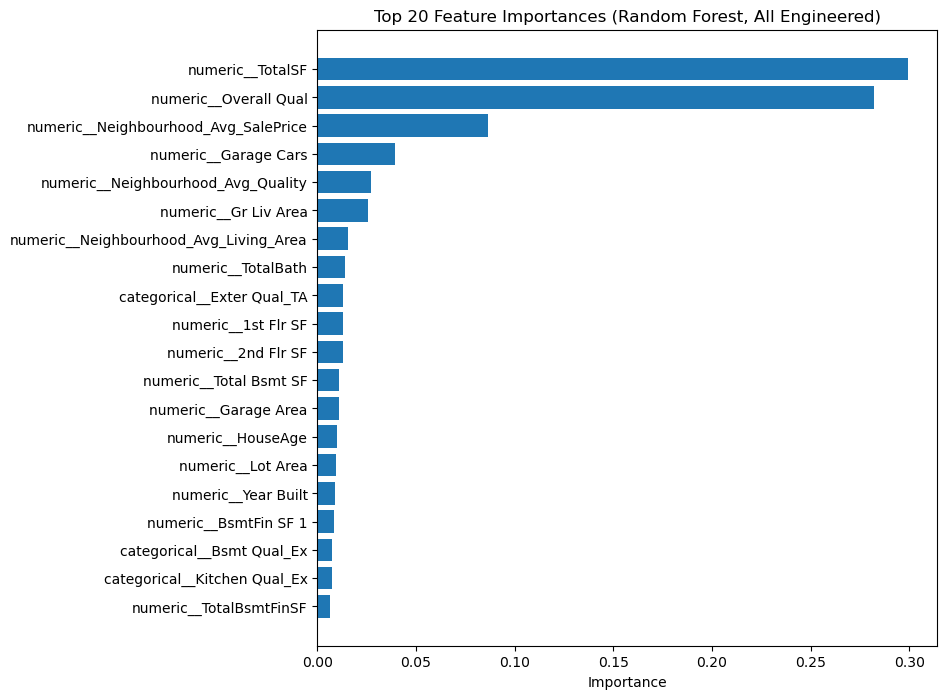

In [112]:
plt.figure(figsize=(8, 8))
top20 = feat_importance_df.head(20)
plt.barh(top20["Feature"][::-1], top20["Importance"][::-1])
plt.title("Top 20 Feature Importances (Random Forest, All Engineered)")
plt.xlabel("Importance")
plt.show()

# SHAP

In [113]:
# Train final tuned XGBoost model
best_xgb_model = xgb_random_search.best_estimator_

In [114]:
# Transform test data
X_test_transformed = best_xgb_model.named_steps[
    "preprocessor"
].transform(X_test_all)

In [115]:
# SHAP explanation
explainer = shap.TreeExplainer(
    best_xgb_model.named_steps["model"]
)

shap_values = explainer(
    X_test_transformed
)

feature_names = (
    best_xgb_model.named_steps[
        "preprocessor"
    ].get_feature_names_out()
)

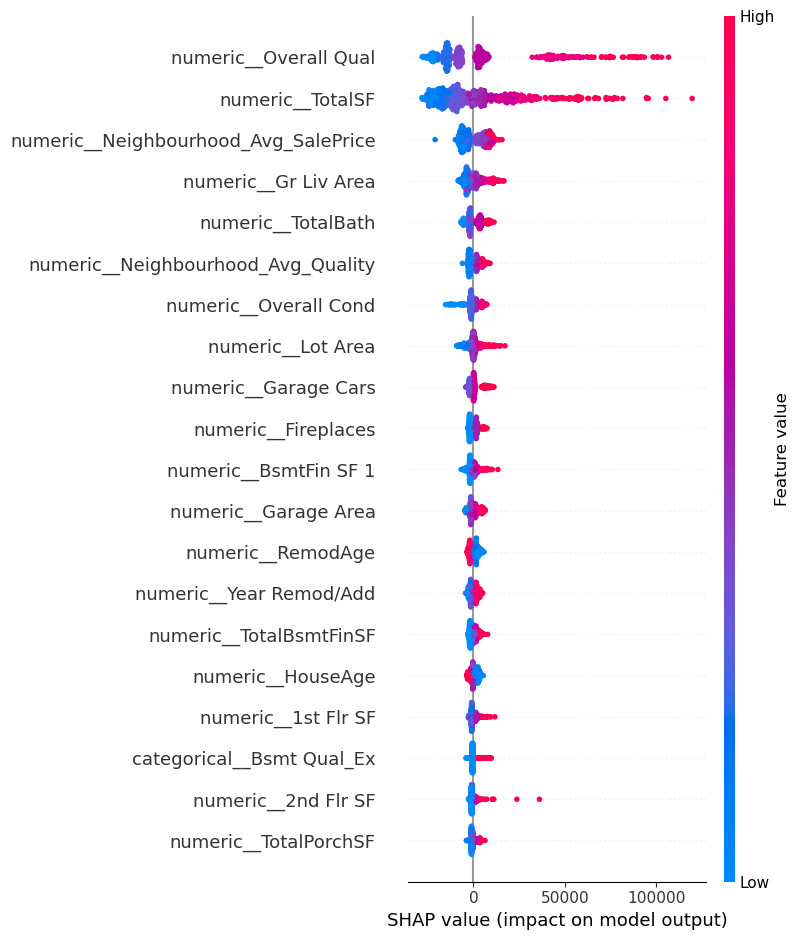

In [116]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

# Residual error analysis across price ranges

In [117]:
final_predictions = best_xgb_model.predict(X_test_all)

residual_analysis = pd.DataFrame({
    "ActualPrice": y_test.values,
    "PredictedPrice": final_predictions
})

residual_analysis["Residual"] = (
    residual_analysis["ActualPrice"]
    - residual_analysis["PredictedPrice"]
)

residual_analysis["AbsoluteError"] = (
    residual_analysis["Residual"].abs()
)

residual_analysis["PriceRange"] = pd.cut(
    residual_analysis["ActualPrice"],
    bins=[0, 150000, 250000, 350000, 500000, np.inf],
    labels=[
        "Low",
        "Medium-Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [118]:
residual_summary = (
    residual_analysis
    .groupby("PriceRange", observed=False)
    .agg(
        Mean_Actual_Price=("ActualPrice", "mean"),
        Mean_Predicted_Price=("PredictedPrice", "mean"),
        Mean_Residual=("Residual", "mean"),
        MAE=("AbsoluteError", "mean")
    )
    .reset_index()
)

In [119]:
residual_summary

,PriceRange,Mean_Actual_Price,Mean_Predicted_Price,Mean_Residual,MAE
0,Low,119528.422131,121849.070312,-2320.653384,9150.650631
1,Medium-Low,193819.463519,195221.687500,-1402.215464,11157.575577
2,Medium,292315.480000,287569.843750,4745.640625,19800.738542
3,High,401807.518519,386533.125000,15274.388889,30810.268519
4,Very High,576918.142857,486892.687500,90025.459821,90025.459821


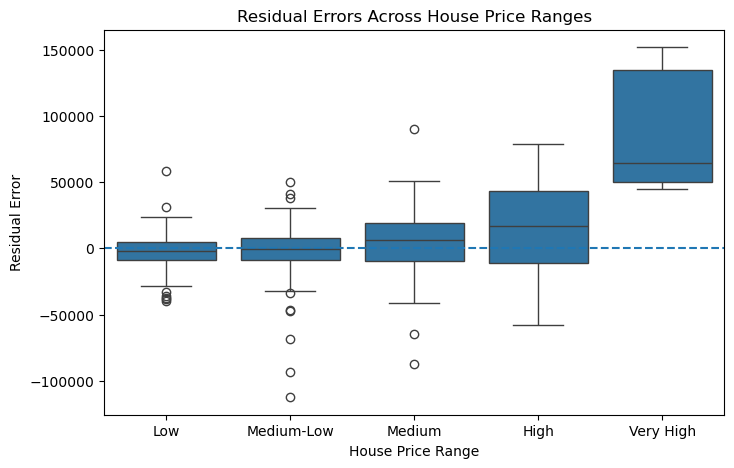

In [120]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=residual_analysis,
    x="PriceRange",
    y="Residual"
)

plt.axhline(0, linestyle="--")
plt.title("Residual Errors Across House Price Ranges")
plt.xlabel("House Price Range")
plt.ylabel("Residual Error")
plt.show()

# Overfitting Check

In [121]:
overfitting_check = []

tuned_candidates = {
    "Linear Regression": linear_pipeline,
    "Random Forest": rf_random_search.best_estimator_,
    "Gradient Boosting": gb_random_search.best_estimator_,
    "XGBoost": xgb_random_search.best_estimator_,
    "CatBoost": catboost_random_search.best_estimator_,
}

for model_name, pipeline in tuned_candidates.items():
    train_r2 = r2_score(y_train, pipeline.predict(X_train_all))
    test_r2 = r2_score(y_test, pipeline.predict(X_test_all))
    gap = train_r2 - test_r2

    overfitting_check.append({
        "Model": model_name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Gap (Train - Test)": gap
    })

overfitting_df = pd.DataFrame(overfitting_check).sort_values("Gap (Train - Test)", ascending=False)
overfitting_df

,Model,Train R2,Test R2,Gap (Train - Test)
1,Random Forest,0.977851,0.924529,0.053323
4,CatBoost,0.987196,0.944236,0.042959
3,XGBoost,0.983854,0.943543,0.040312
2,Gradient Boosting,0.980285,0.940562,0.039723
0,Linear Regression,0.930526,0.894133,0.036394


In [122]:
for _, row in overfitting_df.iterrows():
    gap = row["Gap (Train - Test)"]
    if gap > 0.10:
        verdict = "OVERFITTING"
    elif gap > 0.05:
        verdict = "mild overfitting"
    else:
        verdict = "generalises well"
    print(f"{row['Model']:20s} Train R2={row['Train R2']:.3f}  Test R2={row['Test R2']:.3f}  Gap={gap:.3f}  -> {verdict}")

Random Forest        Train R2=0.978  Test R2=0.925  Gap=0.053  -> mild overfitting
CatBoost             Train R2=0.987  Test R2=0.944  Gap=0.043  -> generalises well
XGBoost              Train R2=0.984  Test R2=0.944  Gap=0.040  -> generalises well
Gradient Boosting    Train R2=0.980  Test R2=0.941  Gap=0.040  -> generalises well
Linear Regression    Train R2=0.931  Test R2=0.894  Gap=0.036  -> generalises well
